# 🛒 Walmart Sales Analytics & Forecasting

## 📌 Project Overview

This project analyzes Walmart's historical weekly sales data to uncover sales trends, seasonal patterns, and the impact of economic factors such as temperature, fuel price, CPI, unemployment, and holidays.

The project also aims to build a predictive model to forecast weekly sales using Machine Learning.

### Objectives
- Understand sales performance across Walmart stores
- Identify seasonal and holiday sales patterns
- Analyze the influence of external economic factors
- Visualize business insights using Python
- Build a sales prediction model

# 📋 Dataset Information

**Dataset:** Walmart Sales Dataset

**Records:** 6,435

**Original Features:** 8

### Dataset Features

| Feature | Description |
|---------|-------------|
| Store | Store Identification Number |
| Date | Weekly observation date |
| Weekly_Sales | Weekly sales revenue |
| Holiday_Flag | Holiday indicator (1 = Holiday, 0 = Non-Holiday) |
| Temperature | Weekly average temperature |
| Fuel_Price | Regional fuel price |
| CPI | Consumer Price Index |
| Unemployment | Regional unemployment rate |

# 📚 Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# 📂 Load Dataset

In [2]:
df = pd.read_csv("Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


# 🔍 Dataset Exploration

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

df.head()

Shape: (6435, 8)

Columns:
Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='str')

Data Types:
Store             int64
Date                str
Weekly_Sales    float64
Holiday_Flag      int64
Temperature     float64
Fuel_Price      float64
CPI             float64
Unemployment    float64
dtype: object


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   str    
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 402.3 KB


### Observation

The dataset contains weekly sales records from multiple Walmart stores with no missing values. The data includes both business and economic indicators that can be used for predictive analysis.

## 📊 Statistical Summary

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,6435.0,2.300000e+01,12.988182,1.000,12.000,23.000000,3.400000e+01,4.500000e+01
Weekly_Sales,6435.0,1.046965e+06,564366.622054,209986.250,553350.105,960746.040000,1.420159e+06,3.818686e+06
Holiday_Flag,6435.0,6.993007e-02,0.255049,0.000,0.000,0.000000,0.000000e+00,1.000000e+00
Temperature,6435.0,6.066378e+01,18.444933,-2.060,47.460,62.670000,7.494000e+01,1.001400e+02
Fuel_Price,6435.0,3.358607e+00,0.459020,2.472,2.933,3.445000,3.735000e+00,4.468000e+00
CPI,6435.0,1.715784e+02,39.356712,126.064,131.735,182.616521,2.127433e+02,2.272328e+02
Unemployment,6435.0,7.999151e+00,1.875885,3.879,6.891,7.874000,8.622000e+00,1.431300e+01


## 🔎 Missing Value Analysis

In [6]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

### Observation

No missing values were detected in the dataset, indicating that no imputation is required before analysis.

## 🔁 Duplicate Record Analysis

In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### Observation

No duplicate records were found, confirming that each observation represents a unique weekly sales record.

# ⚙️ Feature Engineering

In [8]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Month_Name,Quarter
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,February,1
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,February,1
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,February,1
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,February,1
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,March,1


# 📈 Correlation Analysis

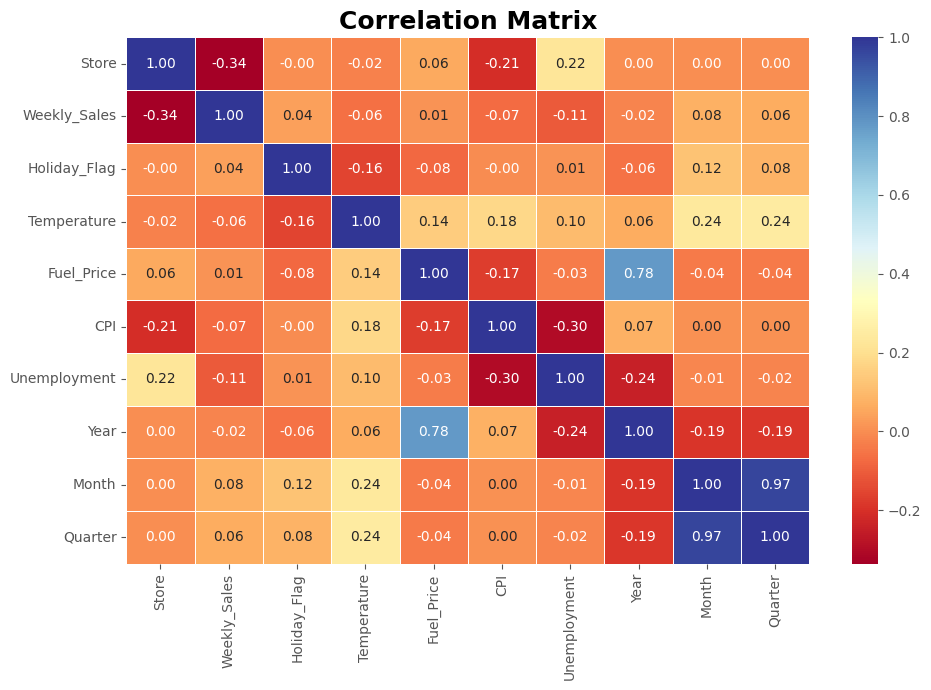

In [9]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="RdYlBu",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Matrix", fontsize=18, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

The correlation matrix indicates that most economic variables have only weak linear relationships with weekly sales, suggesting that sales are influenced by multiple factors rather than a single variable.

# 📊 Exploratory Data Analysis

## Distribution of Weekly Sales

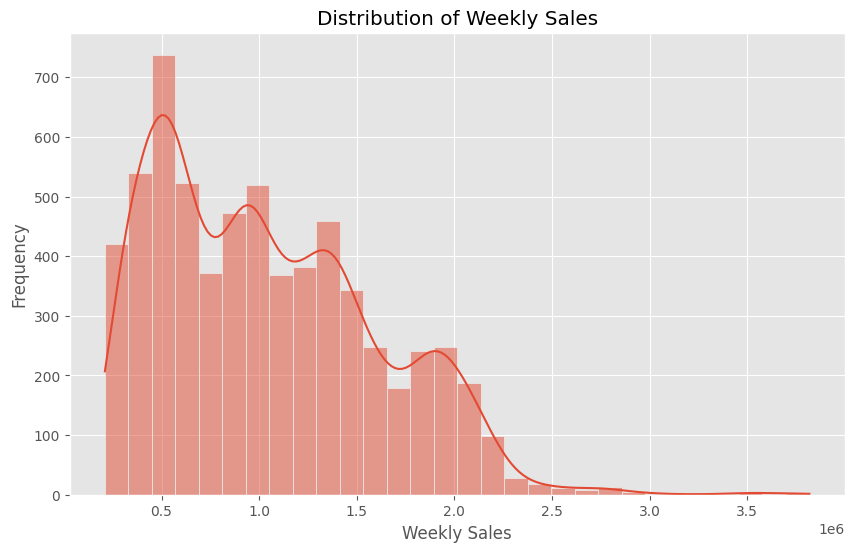

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(df["Weekly_Sales"], bins=30, kde=True)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

### 💡 Insight

Most weekly sales fall within a consistent range, while a few weeks record exceptionally high sales, indicating seasonal demand and promotional events.

## Overall Weekly Sales Trend

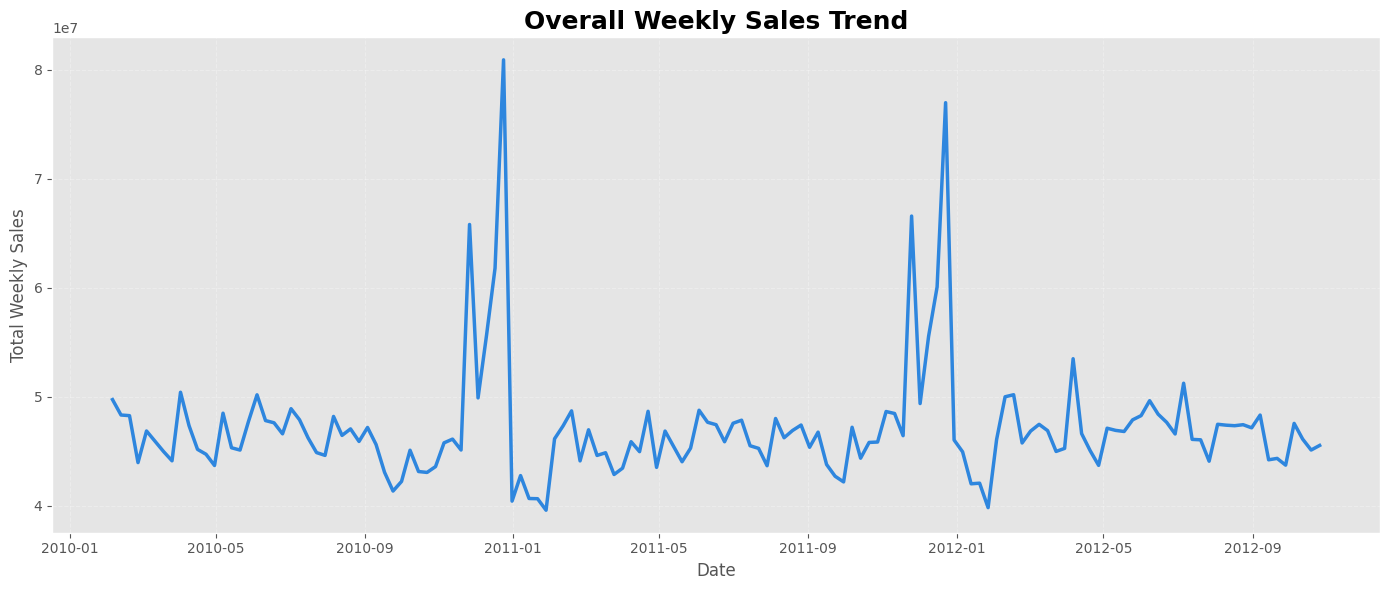

In [11]:
weekly_sales = (
    df.groupby("Date")["Weekly_Sales"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Date"],
    weekly_sales["Weekly_Sales"],
    color="#2E86DE",
    linewidth=2.5
)

plt.title("Overall Weekly Sales Trend", fontsize=18, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Weekly sales fluctuate throughout the year with noticeable spikes during holiday seasons, indicating strong seasonal purchasing behavior.

## Top 10 Walmart Stores by Total Sales

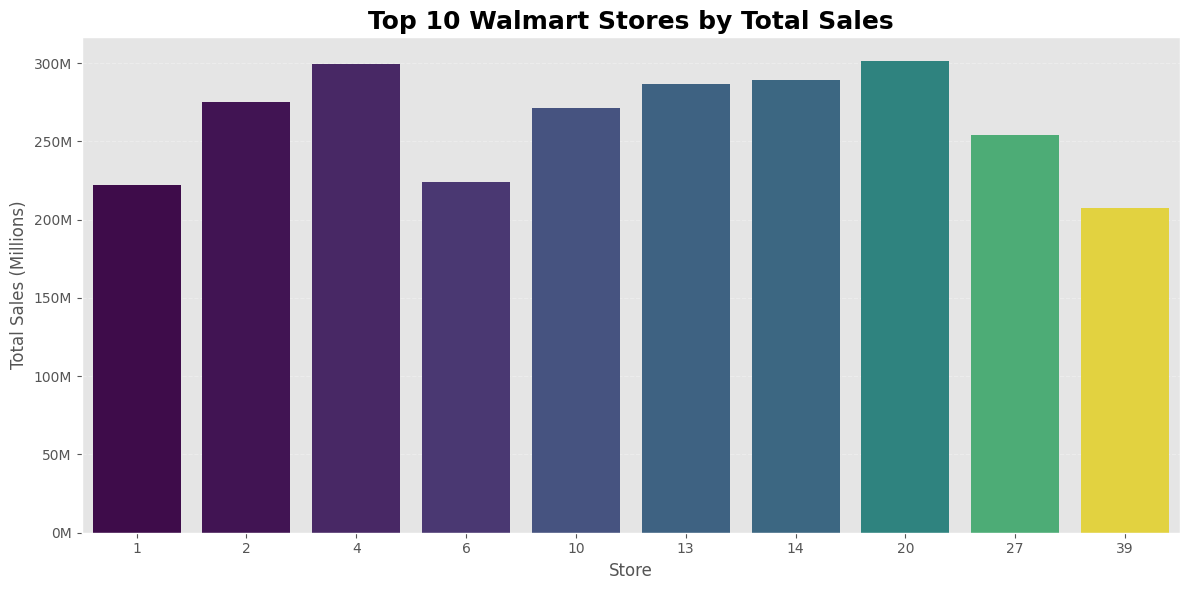

In [12]:
from matplotlib.ticker import FuncFormatter

top_store = (
    df.groupby("Store")["Weekly_Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_store,
    x="Store",
    y="Weekly_Sales",
    hue="Store",
    palette="viridis",
    legend=False
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x/1e6:.0f}M')
)

plt.title("Top 10 Walmart Stores by Total Sales", fontsize=18, fontweight="bold")
plt.xlabel("Store", fontsize=12)
plt.ylabel("Total Sales (Millions)", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

A small number of Walmart stores consistently generate the highest revenue, making them strong contributors to overall sales performance.

## Holiday vs Non-Holiday Sales

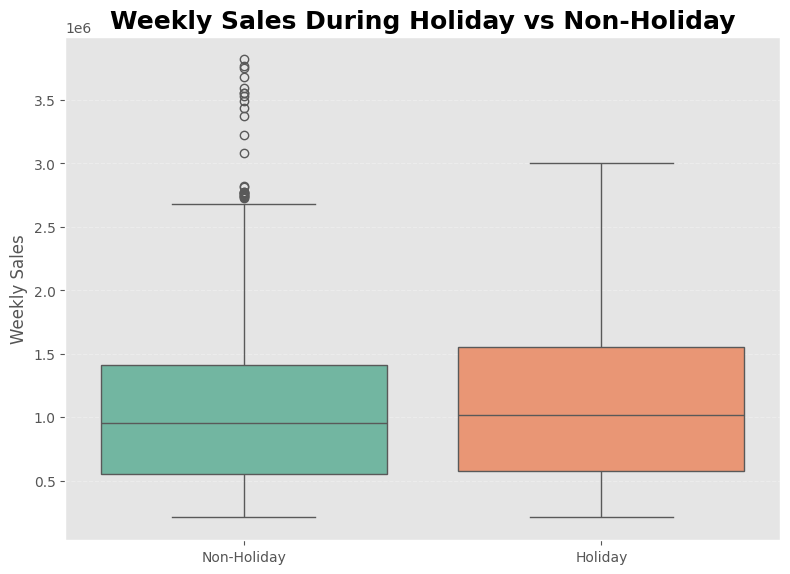

In [13]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Holiday_Flag",
    y="Weekly_Sales",
    hue="Holiday_Flag",
    palette="Set2",
    legend=False
)

plt.xticks([0,1],["Non-Holiday","Holiday"])

plt.title("Weekly Sales During Holiday vs Non-Holiday", fontsize=18, fontweight="bold")
plt.xlabel("")
plt.ylabel("Weekly Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Holiday weeks generally experience higher sales compared to regular weeks because of increased customer demand.

## Average Monthly Sales

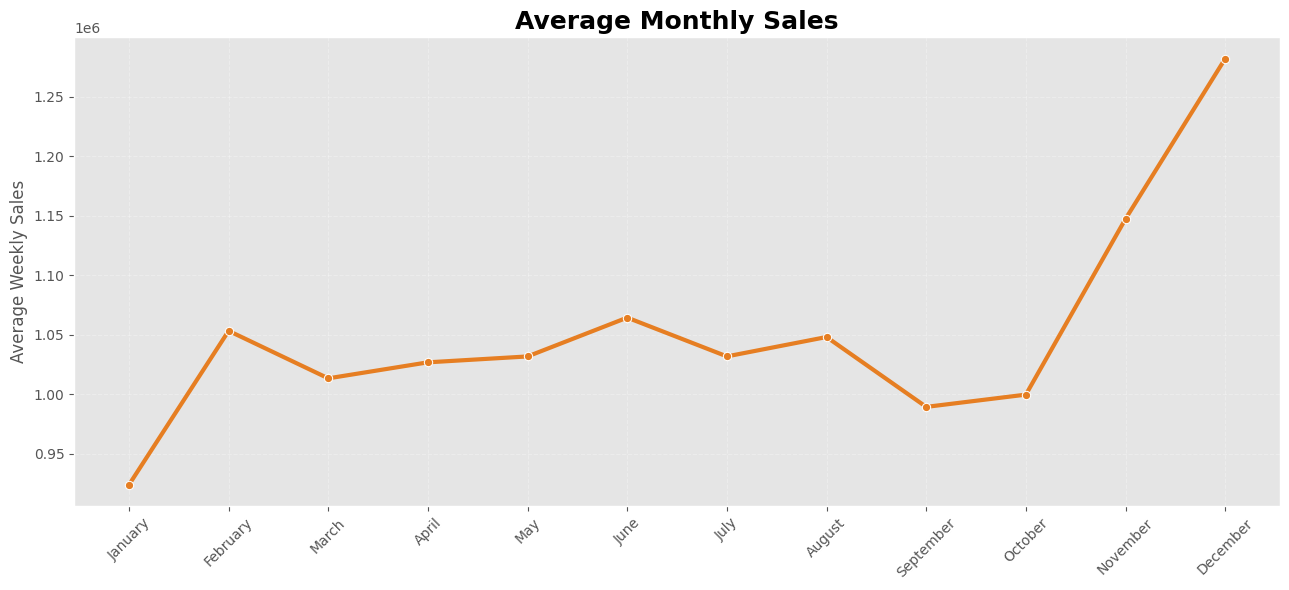

In [14]:
monthly_sales = (
    df.groupby("Month_Name")["Weekly_Sales"]
      .mean()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

plt.figure(figsize=(13,6))

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values,
    marker="o",
    linewidth=3,
    color="#E67E22"
)

plt.title("Average Monthly Sales", fontsize=18, fontweight="bold")
plt.xlabel("")
plt.ylabel("Average Weekly Sales")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Average sales increase toward the end of the year, reflecting holiday shopping and seasonal demand.

## Temperature vs Weekly Sales

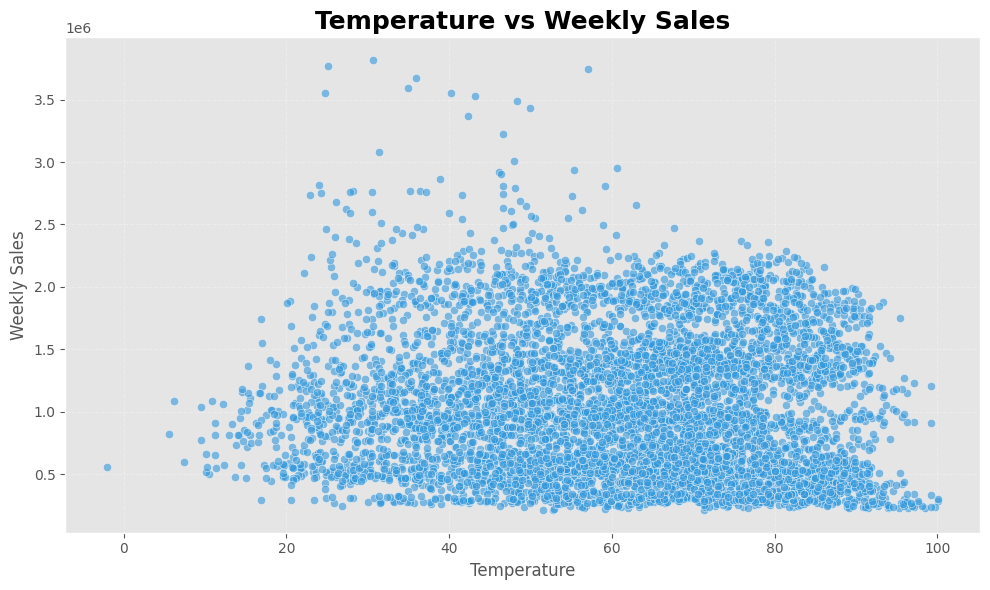

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Temperature",
    y="Weekly_Sales",
    color="#3498DB",
    alpha=0.6
)

plt.title("Temperature vs Weekly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Temperature shows only a weak relationship with weekly sales, indicating weather has limited influence on purchasing behavior.

## Fuel Price vs Weekly Sales

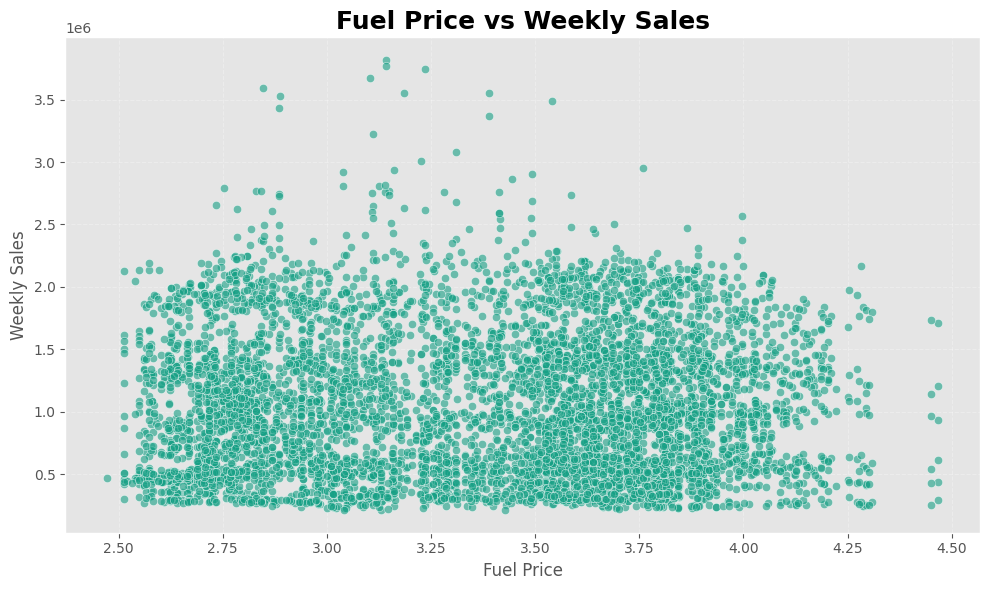

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Fuel_Price",
    y="Weekly_Sales",
    color="#16A085",
    alpha=0.6
)

plt.title("Fuel Price vs Weekly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Fuel Price")
plt.ylabel("Weekly Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Fuel prices show little direct impact on weekly sales, suggesting other business factors influence customer spending more significantly.

## Consumer Price Index (CPI) vs Weekly Sales

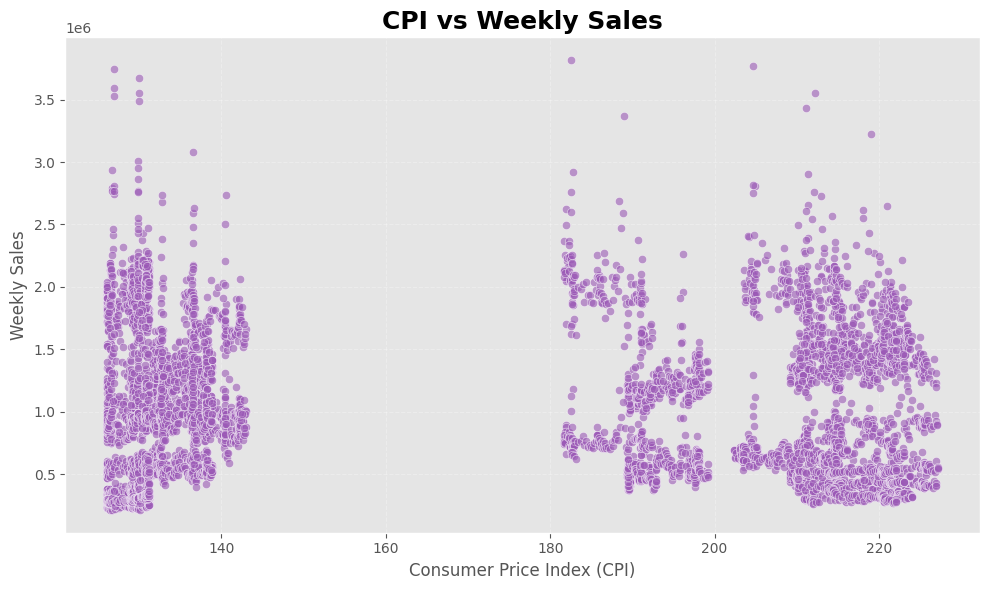

In [17]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="CPI",
    y="Weekly_Sales",
    color="#9B59B6",
    alpha=0.6
)

plt.title("CPI vs Weekly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Consumer Price Index (CPI)")
plt.ylabel("Weekly Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Weekly sales show only a weak relationship with CPI, indicating inflation alone does not strongly influence Walmart's revenue.

## Unemployment Rate vs Weekly Sales

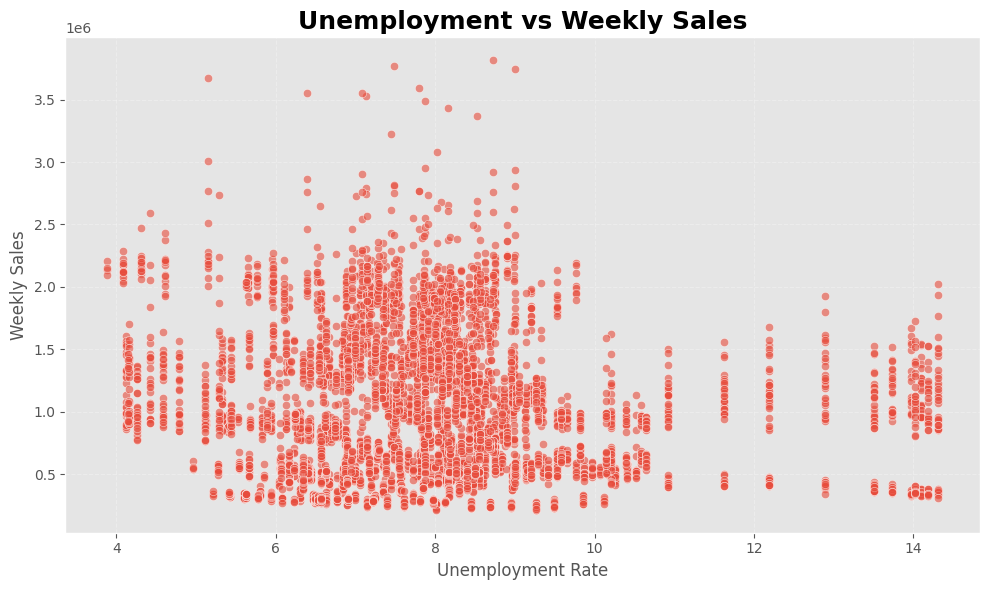

In [18]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Unemployment",
    y="Weekly_Sales",
    color="#E74C3C",
    alpha=0.6
)

plt.title("Unemployment vs Weekly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Unemployment has minimal influence on weekly sales, suggesting customer demand remains relatively stable.

## Average Quarterly Sales

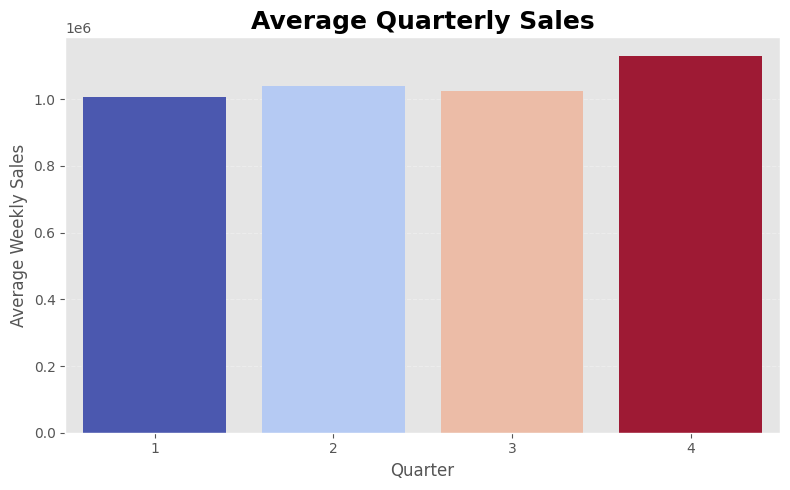

In [19]:
quarter_sales = (
    df.groupby("Quarter")["Weekly_Sales"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=quarter_sales,
    x="Quarter",
    y="Weekly_Sales",
    hue="Quarter",
    palette="coolwarm",
    legend=False
)

plt.title("Average Quarterly Sales", fontsize=18, fontweight="bold")
plt.xlabel("Quarter")
plt.ylabel("Average Weekly Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

### 💡 Insight

Quarterly analysis highlights seasonal business cycles and identifies periods of stronger sales performance.

# 📌 Key Business Findings

- Holiday weeks generally produce higher weekly sales.
- A small number of stores contribute significantly to total revenue.
- Seasonal demand strongly influences sales performance.
- Temperature has only a weak relationship with weekly sales.
- Fuel prices show minimal impact on sales.
- CPI exhibits a weak correlation with sales.
- Unemployment has little influence on Walmart's weekly revenue.

# 🤖 Sales Prediction Using Machine Learning

In this section, machine learning models are developed to predict Walmart's weekly sales using historical sales data and economic indicators.

The performance of multiple regression models is evaluated using standard metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [20]:
X = df[['Store',
        'Holiday_Flag',
        'Temperature',
        'Fuel_Price',
        'CPI',
        'Unemployment',
        'Year',
        'Month',
        'Quarter']]

y = df['Weekly_Sales']

X.head()

,Store,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Quarter
0,1,0,42.31,2.572,211.096358,8.106,2010,2,1
1,1,1,38.51,2.548,211.242170,8.106,2010,2,1
2,1,0,39.93,2.514,211.289143,8.106,2010,2,1
3,1,0,46.63,2.561,211.319643,8.106,2010,2,1
4,1,0,46.50,2.625,211.350143,8.106,2010,3,1


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (5148, 9)
Testing Data  : (1287, 9)


In [22]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [23]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-"*35)
print(f"MAE  : {mae_lr:,.2f}")
print(f"RMSE : {rmse_lr:,.2f}")
print(f"R²   : {r2_lr:.4f}")

Linear Regression Performance
-----------------------------------
MAE  : 432,995.51
RMSE : 521,607.23
R²   : 0.1555


### 📌 Model Insight

Linear Regression establishes a baseline model by assuming a linear relationship between the selected features and weekly sales.

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-"*35)
print(f"MAE  : {mae_rf:,.2f}")
print(f"RMSE : {rmse_rf:,.2f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Performance
-----------------------------------
MAE  : 71,869.41
RMSE : 138,222.06
R²   : 0.9407


### 📌 Model Insight

Random Forest captures complex, non-linear relationships within the dataset and generally provides more accurate predictions than Linear Regression.

In [26]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R² Score": [r2_lr, r2_rf]
})

comparison = comparison.round(2)

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,432995.51,521607.23,0.16
1,Random Forest,71869.41,138222.06,0.94


## Model Selection

Random Forest achieved better predictive performance than Linear Regression by capturing complex non-linear relationships within the data.

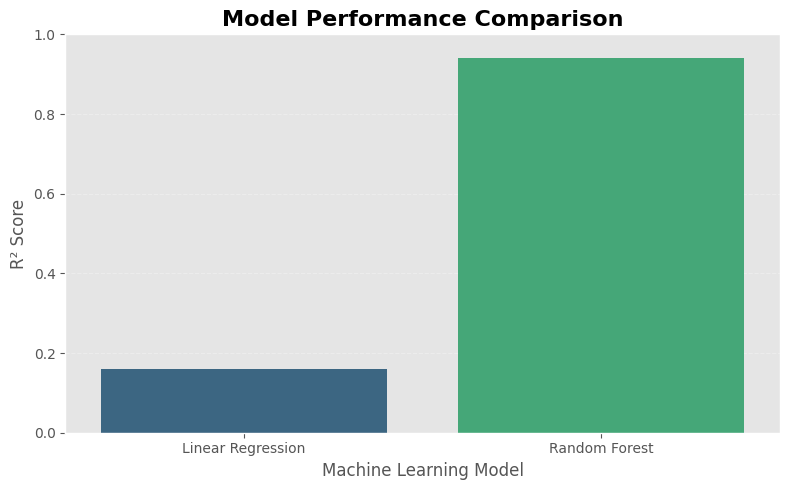

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="R² Score",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Model Performance Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model", fontsize=12)
plt.ylabel("R² Score", fontsize=12)

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## Feature Importance

The Random Forest model ranks features according to their contribution in predicting weekly sales.

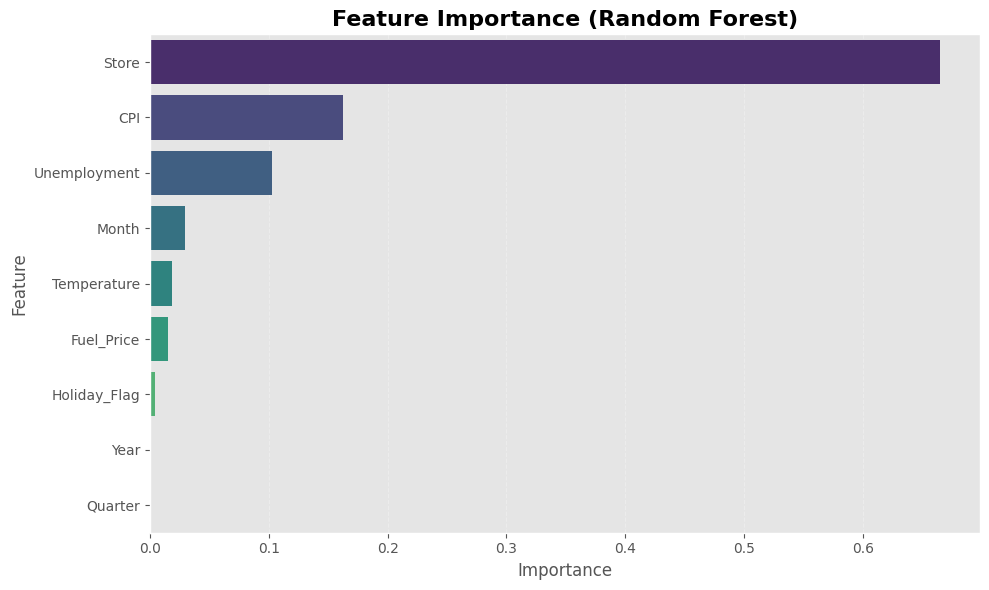

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Feature Importance (Random Forest)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.grid(axis="x", linestyle="--", alpha=0.3)

plt.tight_layout()

plt.show()

## 🏆 Best Performing Model

Based on the evaluation metrics, **Random Forest Regressor** achieved the best predictive performance with a higher R² score and lower prediction error.

Therefore, Random Forest is selected as the final model for weekly sales forecasting.

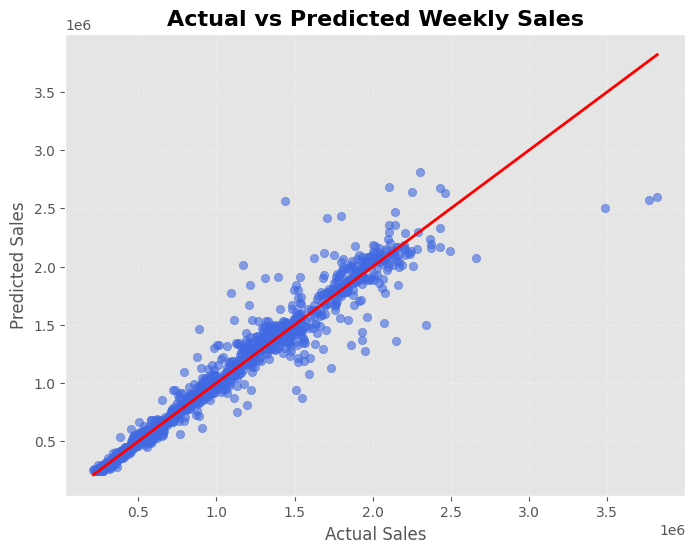

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title(
    "Actual vs Predicted Weekly Sales",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.grid(True, linestyle="--", alpha=0.3)

plt.show()

In [30]:
prediction = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred_rf
})

prediction = prediction.round(2)

prediction.head(10)

,Actual Sales,Predicted Sales
0,1138800.32,1154892.75
1,1304850.67,1398760.01
2,1769296.25,1819719.03
3,1077640.13,971793.32
4,428851.99,429336.22
5,1004523.59,988609.56
6,1523410.71,1177397.64
7,1014898.78,950607.92
8,1955896.59,2045214.68
9,958667.23,955556.16


### Observation

The predicted values closely follow the actual weekly sales, indicating that the Random Forest model generalizes well to unseen data.

# 📊 Project Summary

In [31]:
summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing Values",
        "Duplicate Records",
        "Best Model"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        "Random Forest"
    ]
})

summary

,Metric,Value
0,Rows,6435
1,Columns,12
2,Missing Values,0
3,Duplicate Records,0
4,Best Model,Random Forest


# 🎯 Conclusion

This project analyzed Walmart's weekly sales data to identify sales trends, seasonal patterns, and the impact of external economic factors.

Through exploratory data analysis, meaningful business insights were uncovered regarding store performance, holiday sales, and economic indicators.

Two machine learning models were developed to predict weekly sales. Among them, the **Random Forest Regressor** achieved the best performance, making it the preferred model for sales forecasting.

## Skills Demonstrated

- Data Cleaning
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Data Visualization
- Machine Learning
- Business Insight Generation

The results of this project can support inventory planning, promotional strategies, and data-driven business decisions.